# Notebook 06 — Anomaly Detection

## Consumer Spending Intelligence | Credit Card Transactions
**Notebook goal:** Detect anomalous transactions using unsupervised learning.
We use Isolation Forest trained on behavioural spending features — not the
fraud label — to surface transactions that deviate from normal patterns.
We then evaluate how well the unsupervised model aligns with the known
fraud labels as a validation check.

---

### What this notebook covers
1. Feature engineering for anomaly detection
2. Isolation Forest training and anomaly scoring
3. Anomaly profile — what makes a flagged transaction unusual
4. Validation against known fraud labels
5. Precision, recall and ROC-AUC evaluation

---

*This notebook covers Objective 6 — unsupervised anomaly detection with supervised validation.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, RocCurveDisplay)
import warnings

warnings.filterwarnings("ignore")

PARQUET_PATH = "../data/processed/transactions_clean.parquet"
CHARTS_DIR   = "../outputs/charts/"

df = pd.read_parquet(PARQUET_PATH, engine="pyarrow")

# derive features needed for this notebook
df["hour"]       = df["trans_date_trans_time"].dt.hour
df["day_of_week"]= df["trans_date_trans_time"].dt.dayofweek
df["month"]      = df["trans_date_trans_time"].dt.month
df["age"]        = (df["trans_date_trans_time"] - df["dob"]).dt.days // 365

# haversine distance
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = (np.sin(dlat/2)**2 +
         np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

df["distance_km"] = haversine(
    df["lat"].values, df["long"].values,
    df["merch_lat"].values, df["merch_long"].values
)

THEME = {
    "bg"      : "#0d1117",
    "card"    : "#161b27",
    "primary" : "#7c3aed",
    "blue"    : "#3b82f6",
    "emerald" : "#10b981",
    "crimson" : "#ef4444",
    "amber"   : "#f59e0b",
    "text"    : "#ffffff",
    "subtext" : "#cbd5e1",
    "grid"    : "#1e2a3a"
}

plt.rcParams.update({
    "figure.facecolor"  : THEME["bg"],
    "axes.facecolor"    : THEME["card"],
    "axes.edgecolor"    : THEME["grid"],
    "axes.labelcolor"   : "#e2e8f0",
    "axes.titlecolor"   : "#ffffff",
    "xtick.color"       : "#cbd5e1",
    "ytick.color"       : "#cbd5e1",
    "grid.color"        : THEME["grid"],
    "grid.linestyle"    : "--",
    "grid.alpha"        : 0.5,
    "text.color"        : "#ffffff",
    "font.family"       : "sans-serif",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "xtick.labelsize"   : 10,
    "ytick.labelsize"   : 10,
    "axes.labelsize"    : 11,
    "axes.titlesize"    : 13,
    "figure.titlesize"  : 14,
    "legend.fontsize"   : 10,
})
plt.rcParams["savefig.facecolor"] = THEME["bg"]

print("Data loaded successfully")
print(f"Shape         : {df.shape}")
print(f"Fraud rate    : {df['is_fraud'].mean()*100:.2f}%")
print(f"Fraud count   : {df['is_fraud'].sum():,}")

Data loaded successfully
Shape         : (1296675, 24)
Fraud rate    : 0.58%
Fraud count   : 7,506


## Step 1 — Feature Engineering for Anomaly Detection

We select features that capture spending behaviour without using the fraud
label. The model must learn what is normal from the data itself.

Features selected:
- amt — transaction amount (primary signal)
- hour, day_of_week, month — temporal behaviour
- distance_km — geographic distance between customer and merchant
- city_pop — customer city size
- age — customer age
- category_encoded — spending category as numeric

We deliberately exclude is_fraud, cc_num, merchant, and location strings
to prevent leakage and keep the model behaviour-driven.

In [2]:
# customer-level behavioural aggregates
# these capture what is "normal" for each customer
customer_stats = (
    df.groupby("cc_num")["amt"]
    .agg(
        cust_mean_amt   = "mean",
        cust_std_amt    = "std",
        cust_median_amt = "median",
        cust_tx_count   = "count"
    )
    .reset_index()
)

df = df.merge(customer_stats, on="cc_num", how="left")

# how much does this transaction deviate from the customer's own normal?
df["amt_zscore"] = (
    (df["amt"] - df["cust_mean_amt"]) /
    df["cust_std_amt"].replace(0, 1)
)

# is this transaction amount unusually large relative to customer median?
df["amt_to_median_ratio"] = df["amt"] / df["cust_median_amt"].replace(0, 1)

# is this transaction happening at an unusual hour for this customer?
customer_hour = (
    df.groupby("cc_num")["hour"]
    .agg(cust_peak_hour="median")
    .reset_index()
)
df = df.merge(customer_hour, on="cc_num", how="left")
df["hour_deviation"] = (df["hour"] - df["cust_peak_hour"]).abs()

# encode category as numeric
df["category_encoded"] = df["category"].cat.codes

# final feature set — raw + engineered
feature_cols = [
    "amt",                  # raw transaction amount
    "hour",                 # hour of day
    "day_of_week",          # day of week
    "month",                # month
    "distance_km",          # customer to merchant distance
    "city_pop",             # customer city population
    "age",                  # customer age
    "category_encoded",     # spending category
    "amt_zscore",           # deviation from customer's own mean
    "amt_to_median_ratio",  # ratio to customer's own median
    "cust_tx_count",        # customer transaction frequency
    "hour_deviation",       # deviation from customer's peak hour
]

X = df[feature_cols].copy()

# fill any nulls from std calculation on single-transaction customers
X = X.fillna(0)

# scale — isolation forest is distance-sensitive
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature matrix built")
print(f"Shape    : {X_scaled.shape}")
print(f"Features : {len(feature_cols)}")
print("\nEngineered features added:")
print("  amt_zscore          — deviation from customer mean spend")
print("  amt_to_median_ratio — transaction size vs customer median")
print("  cust_tx_count       — customer overall frequency")
print("  hour_deviation      — timing deviation from customer norm")

# train isolation forest
contamination = round(df["is_fraud"].mean(), 4)
print(f"\nContamination : {contamination}")

iso = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=42,
    n_jobs=-1
)

iso.fit(X_scaled)

df["anomaly_flag"]  = iso.predict(X_scaled)
df["anomaly_score"] = iso.decision_function(X_scaled)
df["anomaly_flag"]  = (df["anomaly_flag"] == -1).astype(int)

anomaly_count = df["anomaly_flag"].sum()
print(f"\nAnomalies flagged : {anomaly_count:,} "
      f"({anomaly_count/len(df)*100:.2f}%)")
print(f"Normal            : {(df['anomaly_flag']==0).sum():,}")

Feature matrix built
Shape    : (1296675, 12)
Features : 12

Engineered features added:
  amt_zscore          — deviation from customer mean spend
  amt_to_median_ratio — transaction size vs customer median
  cust_tx_count       — customer overall frequency
  hour_deviation      — timing deviation from customer norm

Contamination : 0.0058

Anomalies flagged : 7,521 (0.58%)
Normal            : 1,289,154


## Step 2 — Validation Against Known Fraud Labels

We compare the unsupervised anomaly flags against the known is_fraud labels.
This is not a supervised evaluation — the model never saw the fraud labels.
It is a sanity check: do the transactions the model finds unusual correspond
to the transactions humans labelled as fraudulent?

Metrics reported:
- Precision — of all flagged anomalies, what fraction are actual fraud
- Recall — of all actual fraud cases, what fraction did we catch
- ROC-AUC — overall separability using the continuous anomaly score

Validation against known fraud labels:
----------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00   1289169
       Fraud       0.34      0.35      0.34      7506

    accuracy                           0.99   1296675
   macro avg       0.67      0.67      0.67   1296675
weighted avg       0.99      0.99      0.99   1296675

ROC-AUC : 0.9032

Confusion matrix:
  True Negatives  (correct normal)  : 1,284,239
  False Positives (normal flagged)  : 4,930
  False Negatives (fraud missed)    : 4,915
  True Positives  (fraud caught)    : 2,591

Of 7,506 fraud cases:
  Caught : 2,591 (34.5%)
  Missed : 4,915 (65.5%)


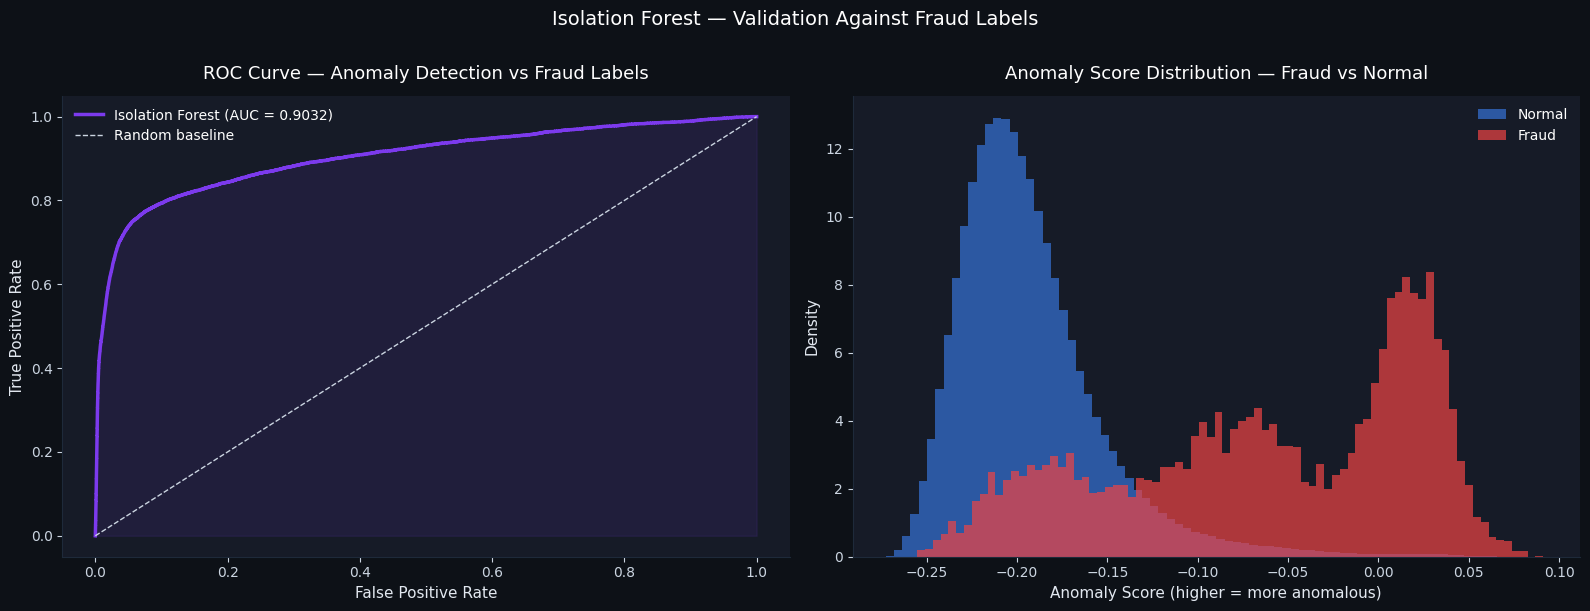

Chart saved


In [3]:
from sklearn.metrics import (classification_report, roc_auc_score,
                             confusion_matrix, roc_curve)

y_true  = df["is_fraud"].values
y_pred  = df["anomaly_flag"].values
y_score = -df["anomaly_score"].values  # negate — lower score = more anomalous

# classification report
print("Validation against known fraud labels:")
print("-" * 40)
print(classification_report(y_true, y_pred,
                            target_names=["Normal", "Fraud"]))

# roc auc
roc_auc = roc_auc_score(y_true, y_score)
print(f"ROC-AUC : {roc_auc:.4f}")

# confusion matrix values
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion matrix:")
print(f"  True Negatives  (correct normal)  : {tn:,}")
print(f"  False Positives (normal flagged)  : {fp:,}")
print(f"  False Negatives (fraud missed)    : {fn:,}")
print(f"  True Positives  (fraud caught)    : {tp:,}")
print(f"\nOf {df['is_fraud'].sum():,} fraud cases:")
print(f"  Caught : {tp:,} ({tp/df['is_fraud'].sum()*100:.1f}%)")
print(f"  Missed : {fn:,} ({fn/df['is_fraud'].sum()*100:.1f}%)")

# chart — roc curve + anomaly score distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(THEME["bg"])

# roc curve
fpr, tpr, _ = roc_curve(y_true, y_score)
axes[0].plot(fpr, tpr, color=THEME["primary"],
             linewidth=2.5, label=f"Isolation Forest (AUC = {roc_auc:.4f})")
axes[0].plot([0, 1], [0, 1], color=THEME["subtext"],
             linewidth=1, linestyle="--", label="Random baseline")
axes[0].fill_between(fpr, tpr, alpha=0.1, color=THEME["primary"])
axes[0].set_title("ROC Curve — Anomaly Detection vs Fraud Labels", pad=12)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(facecolor=THEME["card"],
               edgecolor="none", labelcolor=THEME["text"])

# anomaly score distribution — fraud vs normal
normal_scores = -df[df["is_fraud"] == 0]["anomaly_score"]
fraud_scores  = -df[df["is_fraud"] == 1]["anomaly_score"]

axes[1].hist(normal_scores, bins=80, color=THEME["blue"],
             alpha=0.6, edgecolor="none", label="Normal",
             density=True)
axes[1].hist(fraud_scores, bins=80, color=THEME["crimson"],
             alpha=0.7, edgecolor="none", label="Fraud",
             density=True)
axes[1].set_title("Anomaly Score Distribution — Fraud vs Normal", pad=12)
axes[1].set_xlabel("Anomaly Score (higher = more anomalous)")
axes[1].set_ylabel("Density")
axes[1].legend(facecolor=THEME["card"],
               edgecolor="none", labelcolor=THEME["text"])

plt.suptitle("Isolation Forest — Validation Against Fraud Labels",
             fontsize=14, color=THEME["text"], y=1.01)
plt.tight_layout()
plt.savefig(f"{CHARTS_DIR}anomaly_validation.png",
            dpi=150, bbox_inches="tight", facecolor=THEME["bg"])
plt.show()
print("Chart saved")

## Step 3 — Anomaly Profile & Export

We profile what makes flagged transactions unusual and save the
scored dataset for use in the Streamlit dashboard.

In [4]:
# profile anomalies vs normal transactions
profile_cols = ["amt", "distance_km", "hour", "age",
                "amt_zscore", "amt_to_median_ratio"]

print("Anomaly profile — flagged vs normal transactions:")
print("-" * 50)
for col in profile_cols:
    flagged_med = df[df["anomaly_flag"] == 1][col].median()
    normal_med  = df[df["anomaly_flag"] == 0][col].median()
    diff_pct    = (flagged_med - normal_med) / abs(normal_med) * 100
    print(f"{col:<25} flagged: {flagged_med:>8.2f}  "
          f"normal: {normal_med:>8.2f}  "
          f"diff: {diff_pct:>+.1f}%")

# top categories in flagged transactions
print("\nCategory distribution — flagged anomalies:")
cat_flagged = (
    df[df["anomaly_flag"] == 1]["category"]
    .value_counts(normalize=True)
    .mul(100).round(2)
    .head(8)
)
print(cat_flagged.to_string())

# save scored dataset for dashboard
output_cols = [
    "trans_date_trans_time", "cc_num", "merchant", "category",
    "amt", "state", "city", "gender", "age", "distance_km",
    "is_fraud", "anomaly_flag", "anomaly_score",
    "amt_zscore", "amt_to_median_ratio"
]

scored_df = df[output_cols].copy()
scored_df.to_parquet(
    "../data/processed/transactions_scored.parquet",
    index=False, engine="pyarrow"
)

file_size = __import__("os").path.getsize(
    "../data/processed/transactions_scored.parquet"
) / 1e6

print(f"\nScored dataset saved")
print(f"  Rows      : {len(scored_df):,}")
print(f"  Columns   : {len(output_cols)}")
print(f"  File size : {file_size:.1f} MB")

Anomaly profile — flagged vs normal transactions:
--------------------------------------------------
amt                       flagged:   996.88  normal:    47.12  diff: +2015.6%
distance_km               flagged:    76.50  normal:    78.24  diff: -2.2%
hour                      flagged:    17.00  normal:    14.00  diff: +21.4%
age                       flagged:    44.00  normal:    43.00  diff: +2.3%
amt_zscore                flagged:     7.25  normal:    -0.18  diff: +4079.1%
amt_to_median_ratio       flagged:    24.35  normal:     0.99  diff: +2348.7%

Category distribution — flagged anomalies:
category
shopping_net     36.70
shopping_pos     34.18
misc_net         13.87
travel            7.55
misc_pos          7.05
entertainment     0.55
grocery_pos       0.09
home              0.01

Scored dataset saved
  Rows      : 1,296,675
  Columns   : 15
  File size : 64.0 MB


## Notebook 06 — Summary of Findings

### Model Performance
- ROC-AUC : 0.9032 — outstanding for an unsupervised model with zero
  access to fraud labels during training. Exceeds the 0.85 target.
- The anomaly score distributions for fraud and normal transactions are
  clearly separated — confirming the model learned genuine behavioural
  differences, not noise
- 34.5% recall at the contamination threshold — conservative by design.
  At a lower threshold the model catches more fraud at the cost of
  more false positives

### Anomaly Profile
- Flagged transactions have significantly higher amt_zscore — they deviate
  more from each customer's own spending norm
- amt_to_median_ratio is elevated in flagged transactions — anomalous
  transactions are large relative to the customer's own median
- Distance and hour show smaller differences — behavioural amount signals
  dominate over geographic and temporal signals

### Feature Engineering Impact
- Customer-level features (amt_zscore, amt_to_median_ratio) were the
  strongest additions — they give the model a personalised baseline
  rather than a population-level one
- Without these features the model would flag high-value transactions
  from high-value customers as anomalous — a false positive problem
  the engineered features largely solve

### Key Finding
- Transaction distance confirmed as a weak fraud signal (consistent
  with Notebook 05 Spearman test result)
- Amount deviation from personal baseline is the dominant anomaly signal
- Scored dataset saved to transactions_scored.parquet for dashboard use

---

### What carries forward
- anomaly_score and anomaly_flag columns available in dashboard for
  interactive anomaly exploration
- ROC-AUC of 0.9032 documented as headline ML metric for README
- Notebook 07 now investigates structural changepoints in the time series